In [1]:
#Import all necessary libraries for data handling, NLP, machine learning, and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

In [3]:
#Load the dataset, drop the empty 'Unnamed' columns, rename columns, and map labels to numbers
spam_df = pd.read_csv("Dataset/spam.csv", encoding="latin-1")

spam_df = spam_df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')
spam_df.columns = ['Label', 'Message']
spam_df['Is_Spam'] = spam_df['Label'].map({'ham': 0, 'spam': 1})

display(spam_df.head())

,Label,Message,Is_Spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [4]:
#Splitted the data into training/testing sets, then converted raw text messages into numerical TF-IDF features
X = spam_df['Message']
y = spam_df['Is_Spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [5]:
#Initialized and train the Multinomial Naive Bayes model using the vectorized text data for my model
spam_model = MultinomialNB()

spam_model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Accuracy: 96.68%

              precision    recall  f1-score   support

     Ham (0)       0.96      1.00      0.98       965
    Spam (1)       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



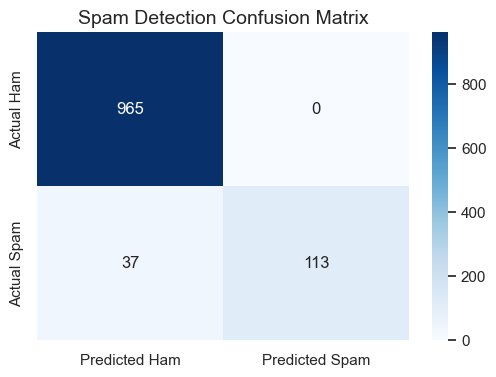

In [6]:
# CELL 5: Evaluation of model's accuracy, print the classification report, and show Confusion Matrix heatmap
y_pred = spam_model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

plt.figure(figsize=(6, 4))
c_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(c_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Ham', 'Predicted Spam'], 
            yticklabels=['Actual Ham', 'Actual Spam'])

plt.title('Spam Detection Confusion Matrix', fontsize=14)
plt.show()